### Environment Setup

In [2]:
!pip install pyriemann mne scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 40.6 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [8]:
import os, mne
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus: tf.config.experimental.set_memory_growth(gpus[0], True)

### Exploratory Data Analysis (EDA)

/tmp/ipykernel_913/3712938890.py:4: RuntimeWarning: Physical range is not defined in following channels:
CPz
  raw_eda = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


<Info | 8 non-empty values
 bads: []
 ch_names: FP1, FP2, Fz, F3, F4, F7, F8, FCz, FC3, FC4, FT7, FT8, Cz, C3, ...
 chs: 30 EEG, 2 EOG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: 2022-12-01 18:58:12 UTC
 nchan: 33
 projs: []
 sfreq: 500.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: Anonymous, birthday: 1951-05-13>
>


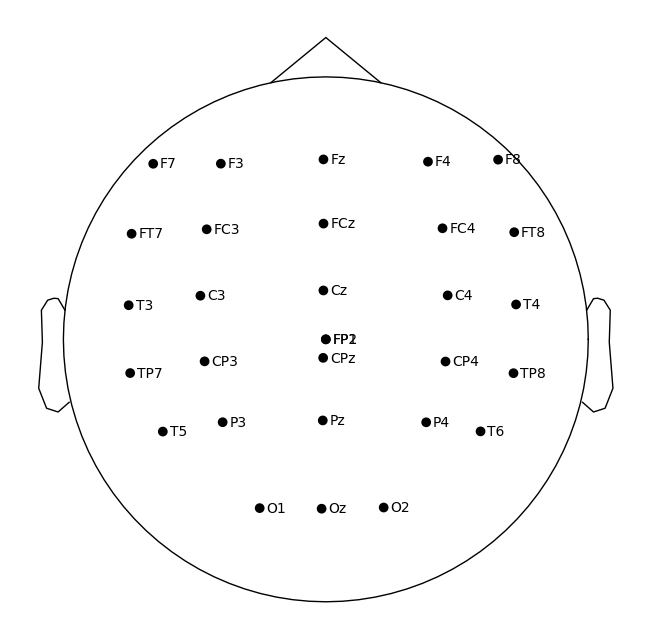

Plotting power spectral density (dB=True).


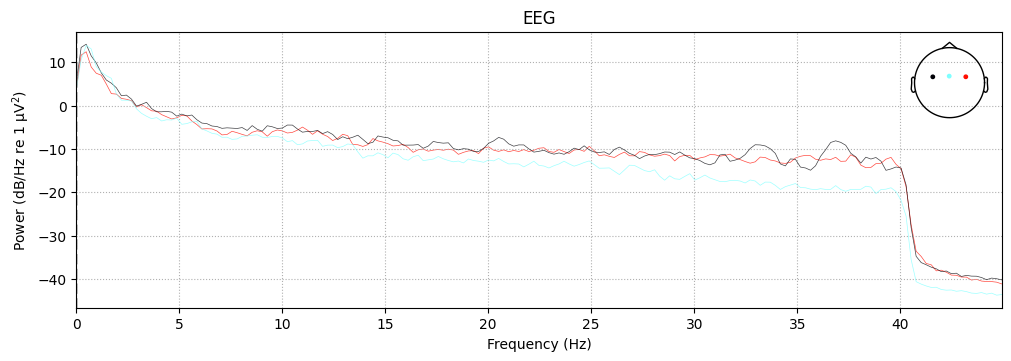

In [ ]:
sub_id = "01"
edf_path = f"/content/drive/MyDrive/edffile/sub-{sub_id}/eeg/sub-{sub_id}_task-motor-imagery_eeg.edf"
if os.path.exists(edf_path):
    raw_eda = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw_eda.rename_channels({'': 'STI'})
    raw_eda.set_channel_types({'HEOL': 'eog', 'HEOR': 'eog', 'STI': 'stim'})

    print(raw_eda.info)
    try:
        raw_eda.set_montage(mne.channels.make_standard_montage('standard_1020'), on_missing='ignore')
        raw_eda.plot_sensors(show_names=True, title="EEG Sensor Map")
        plt.show()
    except: pass

    raw_eda.compute_psd(fmax=45, picks=['C3', 'C4', 'Cz'], verbose=False).plot(show=False)
    plt.show()

### Global Preprocessing & RAM Caching
To avoid re-computing heavy ICA and filtering for every method, we process all patients exactly ONCE and cache their clean data in RAM.

In [ ]:
def load_subject_data(sub_id):
    edf_path = f"/content/drive/MyDrive/edffile/sub-{sub_id}/eeg/sub-{sub_id}_task-motor-imagery_eeg.edf"
    mat_path = f"/content/drive/MyDrive/sourcedata/sourcedata/sub-{sub_id}/sub-{sub_id}_task-motor-imagery_eeg.mat"
    if not os.path.exists(edf_path): return None, None, None

    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.rename_channels({'': 'STI'})
    raw.set_channel_types({'HEOL': 'eog', 'HEOR': 'eog', 'STI': 'stim'})
    raw.filter(l_freq=8., h_freq=30., picks=['eeg'], verbose=False)

    ica = mne.preprocessing.ICA(n_components=15, max_iter='auto', random_state=42)
    ica.fit(raw, picks=['eeg'], verbose=False)
    eog_indices, _ = ica.find_bads_eog(raw, ch_name=['HEOL', 'HEOR'], verbose=False)
    ica.exclude = eog_indices
    ica.apply(raw, verbose=False)

    labels = sio.loadmat(mat_path)['eeg']['label'][0, 0].flatten() - 1
    stim = raw.get_data(picks=['STI'])[0]
    pos = np.where((stim > 1.5e-6) & (stim < 2.5e-6))[0]
    valid_pos = pos[np.insert(np.diff(pos) > 1000, 0, True)][:min(len(pos), len(labels))]

    events = np.column_stack((valid_pos, np.zeros(len(valid_pos), dtype=int), np.ones(len(valid_pos), dtype=int)))
    epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=4, baseline=None, preload=True, verbose=False)
    epochs_eeg = epochs.copy().pick_types(eeg=True, eog=False, stim=False)
    return epochs_eeg.get_data(), labels[:len(valid_pos)], epochs_eeg.ch_names

In [ ]:
print("Running Global Preprocessing and caching to RAM...")
preprocessed_cache = {}
for sub in [f"{i:02d}" for i in range(1, 51)]:
    X, y, ch_names = load_subject_data(sub)
    if X is not None:
        preprocessed_cache[sub] = (X, y, ch_names)
        print(f"Subject {sub} cleaned and cached.")

Running Global Preprocessing and caching to RAM...


/tmp/ipykernel_913/1952119653.py:6: RuntimeWarning: Physical range is not defined in following channels:
CPz
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 01 cleaned and cached.


/tmp/ipykernel_913/1952119653.py:6: RuntimeWarning: Physical range is not defined in following channels:
CPz
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 02 cleaned and cached.


...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 48 cleaned and cached.


/tmp/ipykernel_913/1952119653.py:6: RuntimeWarning: Physical range is not defined in following channels:
CPz
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 49 cleaned and cached.


/tmp/ipykernel_913/1952119653.py:6: RuntimeWarning: Physical range is not defined in following channels:
CPz
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 50 cleaned and cached.


In [5]:
import joblib

# Define the path to save the cache file to your Google Drive
save_cache_filepath = '/content/drive/MyDrive/preprocessed_eeg_cache.pkl'

# Save the preprocessed_cache dictionary
joblib.dump(preprocessed_cache, save_cache_filepath)
print(f"Preprocessed cache saved to: {save_cache_filepath}")

In [6]:
# Define the path to load the cache file from your Google Drive
cache_filepath = '/content/drive/MyDrive/preprocessed_eeg_cache.pkl'

# Load the preprocessed_cache dictionary
preprocessed_cache = joblib.load(cache_filepath)
print(f"Preprocessed cache loaded from: {cache_filepath}")

print(preprocessed_cache.keys())

Preprocessed cache loaded from: /content/drive/MyDrive/preprocessed_eeg_cache.pkl
dict_keys(['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50'])


### Pipeline Visualization (Deep Dive on Subject 01)
Visualized the trigger extraction, frequency filtering, artifact removal, and data augmentation to prove the pipeline's integrity.



--- PIPELINE INTEGRITY ANALYSIS (SUBJECT 01) ---

1. TRIGGER ANALYSIS:
Successfully isolated 40 Marker-2 triggers.
First 3 trigger samples & voltages:
 - Sample: 1003, Voltage: 2e-06
 - Sample: 5002, Voltage: 2e-06
 - Sample: 9002, Voltage: 2e-06

2. FREQUENCY ANALYSIS (PSD):


/tmp/ipykernel_913/2382141882.py:3: RuntimeWarning: Physical range is not defined in following channels:
CPz
  raw_viz = mne.io.read_raw_edf(f"/content/drive/MyDrive/edffile/sub-01/eeg/sub-01_task-motor-imagery_eeg.edf", preload=True, verbose=False)


Plotting power spectral density (dB=True).


/tmp/ipykernel_913/2382141882.py:18: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_viz.compute_psd(fmax=50, picks=['C3', 'C4'], verbose=False).plot(axes=ax[0], show=False)


Plotting power spectral density (dB=True).


/tmp/ipykernel_913/2382141882.py:22: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_viz.compute_psd(fmax=50, picks=['C3', 'C4'], verbose=False).plot(axes=ax[1], show=False)


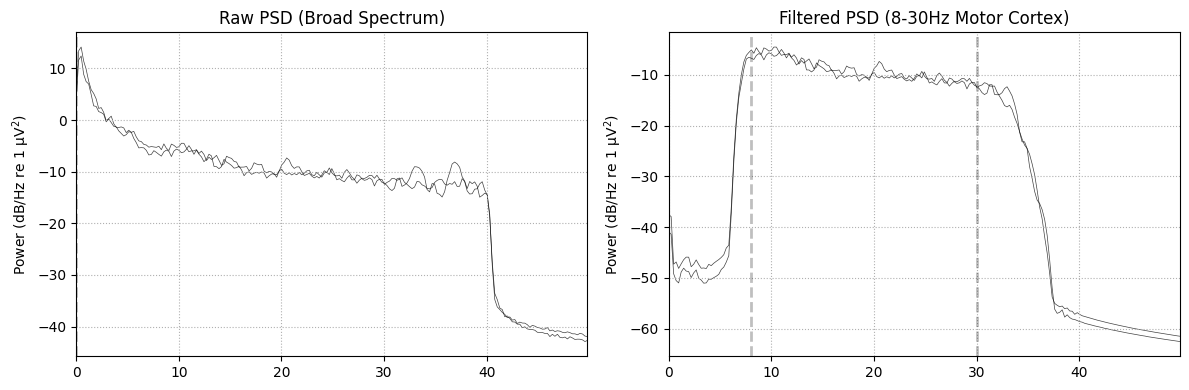


3. ARTIFACT REMOVAL (ICA):
Automatically detected and excluded EOG (Eye-Blink) Components: []

4. DATA AUGMENTATION:


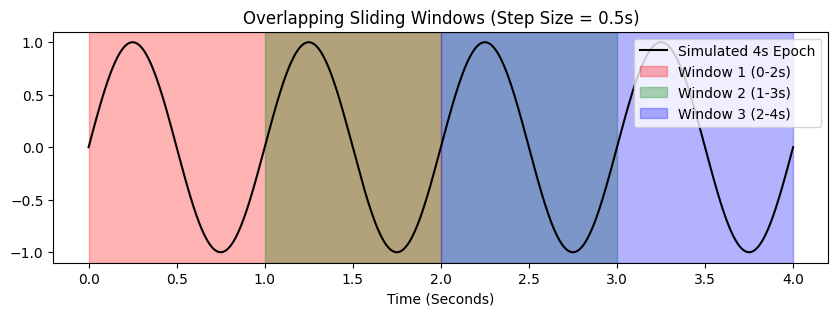

In [ ]:
if "01" in preprocessed_cache:
    print("\n--- PIPELINE INTEGRITY ANALYSIS (SUBJECT 01) ---")
    raw_viz = mne.io.read_raw_edf(f"/content/drive/MyDrive/edffile/sub-01/eeg/sub-01_task-motor-imagery_eeg.edf", preload=True, verbose=False)
    raw_viz.rename_channels({'': 'STI'})
    raw_viz.set_channel_types({'HEOL': 'eog', 'HEOR': 'eog', 'STI': 'stim'})

    # 1. Trigger Analysis
    stim = raw_viz.get_data(picks=['STI'])[0]
    nonzero_idx = np.where((stim > 1.5e-6) & (stim < 2.5e-6))[0]
    print(f"\n1. TRIGGER ANALYSIS:")
    print(f"Successfully isolated {len(nonzero_idx)} Marker-2 triggers.")
    print("First 3 trigger samples & voltages:")
    for idx in nonzero_idx[:3]: print(f" - Sample: {idx}, Voltage: {stim[idx]}")

    # 2. Raw vs Filtered PSD
    print(f"\n2. FREQUENCY ANALYSIS (PSD):")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    raw_viz.compute_psd(fmax=50, picks=['C3', 'C4'], verbose=False).plot(axes=ax[0], show=False)
    ax[0].set_title("Raw PSD (Broad Spectrum)")

    raw_viz.filter(l_freq=8., h_freq=30., picks=['eeg'], verbose=False)
    raw_viz.compute_psd(fmax=50, picks=['C3', 'C4'], verbose=False).plot(axes=ax[1], show=False)
    ax[1].set_title("Filtered PSD (8-30Hz Motor Cortex)")
    plt.tight_layout()
    plt.show()

    # 3. ICA Components
    print(f"\n3. ARTIFACT REMOVAL (ICA):")
    ica_viz = mne.preprocessing.ICA(n_components=15, max_iter='auto', random_state=42)
    ica_viz.fit(raw_viz, picks=['eeg'], verbose=False)
    eog_indices, _ = ica_viz.find_bads_eog(raw_viz, ch_name=['HEOL', 'HEOR'], verbose=False)
    print(f"Automatically detected and excluded EOG (Eye-Blink) Components: {eog_indices}")

    # 4. Overlapping Windows Visualization
    print(f"\n4. DATA AUGMENTATION:")
    plt.figure(figsize=(10,3))
    plt.plot(np.linspace(0, 4, 2000), np.sin(np.linspace(0, 8*np.pi, 2000)), label='Simulated 4s Epoch', color='black')
    plt.axvspan(0, 2.0, color='red', alpha=0.3, label='Window 1 (0-2s)')
    plt.axvspan(1.0, 3.0, color='green', alpha=0.3, label='Window 2 (1-3s)')
    plt.axvspan(2.0, 4.0, color='blue', alpha=0.3, label='Window 3 (2-4s)')
    plt.title("Overlapping Sliding Windows (Step Size = 0.5s)")
    plt.xlabel("Time (Seconds)")
    plt.legend(loc='upper right')
    plt.show()

### Baseline Testing (CSP + LDA)
The CSP algorithm is applied on motor cortex channels to focus on task-relevant EEG activity.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from mne.decoding import CSP
print("Evaluating CSP + LDA (7 Motor Channels)...")
csp_motor_scores = []
for sub, (X, y, ch_names) in preprocessed_cache.items():
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    s_acc = []
    for tr, te in kf.split(X, y):
        from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

        m_idx = [ch_names.index(c) for c in ['C3','C4','Cz','CP3','CP4','FC3','FC4'] if c in ch_names]
        X_tr_m, X_te_m = X[tr][:, m_idx, :], X[te][:, m_idx, :]

        clf = Pipeline([('CSP', CSP(4, reg='ledoit_wolf', log=True)), ('LDA', LinearDiscriminantAnalysis())])
        clf.fit(X_tr_m, y[tr])
        s_acc.append(accuracy_score(y[te], clf.predict(X_te_m)))

    csp_motor_scores.append(np.mean(s_acc))
    print(f"Sub {sub} CSP (7 Ch): {csp_motor_scores[-1]*100:.1f}%")

print(f"\nFINAL CSP (7 CHANNELS) AVERAGE: {np.mean(csp_motor_scores)*100:.2f}%")

Evaluating CSP + LDA (7 Motor Channels)...
Computing rank from data with rank=None
    Using tolerance 1.3e-06 (2.2e-16 eps * 7 dim * 8.2e+08  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.4e-06 (2.2e-16 eps * 7 dim * 8.7e+08  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.4e-06 (2.2e-16 eps * 7 dim * 8.8e+08  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estima

### FBCSP + SVM (Paper Replication)
Included Filter Bank CSP (FBCSP) to align with the filter-bank methodology described in the original paper.

In [ ]:
from scipy.signal import butter, filtfilt

def apply_filter_bank(X, fs=500):
    bands = [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
    return [filtfilt(b, a, X, axis=2) for b, a in [butter(4, [l/(fs/2), h/(fs/2)], btype='bandpass') for l, h in bands]]

print("Evaluating FBCSP + SVM...")
fbcsp_scores = []
for sub, (X, y, ch_names) in preprocessed_cache.items():
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    s_acc = []
    for tr, te in kf.split(X, y):
        m_idx = [ch_names.index(c) for c in ['C3','C4','Cz','CP3','CP4','FC3','FC4'] if c in ch_names]
        X_fb_tr, X_fb_te = apply_filter_bank(X[tr][:, m_idx, :]), apply_filter_bank(X[te][:, m_idx, :])

        X_tr_feat, X_te_feat = [], []
        for b_tr, b_te in zip(X_fb_tr, X_fb_te):
            csp = CSP(4, reg='ledoit_wolf', log=True)
            X_tr_feat.append(csp.fit_transform(b_tr, y[tr]))
            X_te_feat.append(csp.transform(b_te))

        svm_fbcsp = SVC(kernel='rbf', C=1.0).fit(np.hstack(X_tr_feat), y[tr])
        s_acc.append(accuracy_score(y[te], svm_fbcsp.predict(np.hstack(X_te_feat))))

    fbcsp_scores.append(np.mean(s_acc))
    print(f"Sub {sub} FBCSP: {fbcsp_scores[-1]*100:.1f}%")

print(f"\nFINAL FBCSP AVERAGE: {np.mean(fbcsp_scores)*100:.2f}%")

Streaming output truncated to the last 5000 lines.
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 6.5e-07 (2.2e-16 eps * 7 dim * 4.2e+08  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 4.9e-07 (2.2e-16 eps * 7 dim * 3.2e+08  max singular value)
    Estimated rank (data): 7
    data: rank 7 computed from 7 data channels with 0 projectors
Reducing data rank from 7 -> 7
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Sub 28 FBC

### Advanced Mathematics (FBTS & Riemannian Geometry)

In [ ]:
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

print("Evaluating Filter Bank Tangent Space...")
fbts_scores = []
for sub, (X, y, ch_names) in preprocessed_cache.items():
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    s_acc = []
    for tr, te in kf.split(X, y):
        m_idx = [ch_names.index(c) for c in ['C3','C4','Cz','CP3','CP4','FC3','FC4'] if c in ch_names]
        X_fb_tr, X_fb_te = apply_filter_bank(X[tr][:, m_idx, :]), apply_filter_bank(X[te][:, m_idx, :])

        X_tr_ts, X_te_ts = [], []
        for b_tr, b_te in zip(X_fb_tr, X_fb_te):
            ts, cov = TangentSpace(metric='riemann'), Covariances('oas')
            X_tr_ts.append(ts.fit_transform(cov.fit_transform(b_tr)))
            X_te_ts.append(ts.transform(cov.transform(b_te)))

        svm_ts = SVC(kernel='linear', C=1.0).fit(np.hstack(X_tr_ts), y[tr])
        s_acc.append(accuracy_score(y[te], svm_ts.predict(np.hstack(X_te_ts))))

    fbts_scores.append(np.mean(s_acc))
    print(f"Sub {sub} FBTS: {fbts_scores[-1]*100:.1f}%")

print(f"\nFINAL FBTS AVERAGE: {np.mean(fbts_scores)*100:.2f}%")

Evaluating Filter Bank Tangent Space...
Sub 01 FBTS: 20.0%
Sub 02 FBTS: 47.5%
Sub 03 FBTS: 45.0%
Sub 04 FBTS: 40.0%
Sub 05 FBTS: 40.0%
Sub 06 FBTS: 27.5%
Sub 07 FBTS: 52.5%
Sub 08 FBTS: 57.5%
Sub 09 FBTS: 65.0%
Sub 10 FBTS: 50.0%
Sub 11 FBTS: 70.0%
Sub 12 FBTS: 47.5%
Sub 13 FBTS: 50.0%
Sub 14 FBTS: 50.0%
Sub 15 FBTS: 70.0%
Sub 16 FBTS: 35.0%
Sub 17 FBTS: 50.0%
Sub 18 FBTS: 37.5%
Sub 19 FBTS: 65.0%
Sub 20 FBTS: 95.0%
Sub 21 FBTS: 55.0%
Sub 22 FBTS: 72.5%
Sub 23 FBTS: 75.0%
Sub 24 FBTS: 67.5%
Sub 25 FBTS: 52.5%
Sub 26 FBTS: 55.0%
Sub 27 FBTS: 40.0%
Sub 28 FBTS: 62.5%
Sub 29 FBTS: 50.0%
Sub 30 FBTS: 62.5%
Sub 31 FBTS: 45.0%
Sub 32 FBTS: 30.0%
Sub 33 FBTS: 62.5%
Sub 34 FBTS: 42.5%
Sub 35 FBTS: 50.0%
Sub 36 FBTS: 80.0%
Sub 37 FBTS: 92.5%
Sub 38 FBTS: 42.5%
Sub 39 FBTS: 45.0%
Sub 40 FBTS: 82.5%
Sub 41 FBTS: 42.5%
Sub 42 FBTS: 72.5%
Sub 43 FBTS: 50.0%
Sub 44 FBTS: 65.0%
Sub 45 FBTS: 60.0%
Sub 46 FBTS: 62.5%
Sub 47 FBTS: 45.0%
Sub 48 FBTS: 45.0%
Sub 49 FBTS: 45.0%
Sub 50 FBTS: 40.0%

FINAL FBT

### Deep Learning (EEGNet)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Dropout, Input, Flatten, Conv2D, AveragePooling2D, SeparableConv2D, DepthwiseConv2D, BatchNormalization
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import EarlyStopping

def normalize_data(X):
    mean, std = np.mean(X, axis=2, keepdims=True), np.std(X, axis=2, keepdims=True)
    std[std == 0] = 1e-8
    return (X - mean) / std

def build_eegnet(nb_classes=1, Chans=30, Samples=1000):
    input1 = Input(shape=(Chans, Samples, 1))
    b1 = Conv2D(8, (1, 250), padding='same', use_bias=False)(input1)
    b1 = BatchNormalization(axis=-1)(b1)
    b1 = DepthwiseConv2D((Chans, 1), use_bias=False, depth_multiplier=2, depthwise_constraint=max_norm(1.))(b1)
    b1 = BatchNormalization(axis=-1)(b1)
    b1 = Activation('elu')(b1)
    b1 = AveragePooling2D((1, 4))(b1)
    b1 = Dropout(0.5)(b1)
    b2 = SeparableConv2D(16, (1, 16), use_bias=False, padding='same')(b1)
    b2 = BatchNormalization(axis=-1)(b2)
    b2 = Activation('elu')(b2)
    b2 = AveragePooling2D((1, 8))(b2)
    b2 = Dropout(0.5)(b2)
    out = Activation('sigmoid')(Dense(nb_classes, kernel_constraint=max_norm(0.25))(Flatten()(b2)))
    model = Model(inputs=input1, outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def create_overlapping_windows(X, y, window_size=1000, step_size=500):
    X_out, y_out = [], []
    for i in range(len(X)):
        for start in range(0, X.shape[2] - window_size + 1, step_size):
            X_out.append(X[i, :, start:start+window_size])
            y_out.append(y[i])
    return np.array(X_out), np.array(y_out)

In [ ]:
print("Evaluating EEGNet...")
eegnet_scores = []
from sklearn.model_selection import train_test_split
for sub, (X, y, ch_names) in preprocessed_cache.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_tr_aug, y_tr_aug = create_overlapping_windows(X_tr, y_tr)
    X_te_aug, y_te_aug = create_overlapping_windows(X_te, y_te, window_size=1000, step_size=1000)

    X_tr_dl, X_te_dl = normalize_data(X_tr_aug)[..., np.newaxis], normalize_data(X_te_aug)[..., np.newaxis]

    tf.keras.backend.clear_session()
    eegnet = build_eegnet(Chans=30, Samples=X_tr_dl.shape[2])
    eegnet.fit(X_tr_dl, y_tr_aug, epochs=100, batch_size=16, validation_data=(X_te_dl, y_te_aug),
               callbacks=[EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)], verbose=0)

    acc = eegnet.evaluate(X_te_dl, y_te_aug, verbose=0)[1]
    eegnet_scores.append(acc)
    print(f"Sub {sub} EEGNet: {acc*100:.1f}%")

print(f"\nFINAL EEGNet AVERAGE: {np.mean(eegnet_scores)*100:.2f}%")


Evaluating EEGNet...
Sub 01 EEGNet: 75.0%
Sub 02 EEGNet: 81.2%
Sub 03 EEGNet: 68.8%
Sub 04 EEGNet: 50.0%
Sub 05 EEGNet: 56.2%
Sub 06 EEGNet: 50.0%
Sub 07 EEGNet: 75.0%
Sub 08 EEGNet: 56.2%
Sub 09 EEGNet: 68.8%
Sub 10 EEGNet: 56.2%
Sub 11 EEGNet: 56.2%
Sub 12 EEGNet: 68.8%
Sub 13 EEGNet: 75.0%
Sub 14 EEGNet: 50.0%
Sub 15 EEGNet: 62.5%
Sub 16 EEGNet: 68.8%
Sub 17 EEGNet: 50.0%
Sub 18 EEGNet: 68.8%
Sub 19 EEGNet: 68.8%
Sub 20 EEGNet: 50.0%
Sub 21 EEGNet: 43.8%
Sub 22 EEGNet: 75.0%
Sub 23 EEGNet: 56.2%
Sub 24 EEGNet: 50.0%
Sub 25 EEGNet: 50.0%
Sub 26 EEGNet: 62.5%
Sub 27 EEGNet: 75.0%
Sub 28 EEGNet: 68.8%
Sub 29 EEGNet: 56.2%
Sub 30 EEGNet: 68.8%
Sub 31 EEGNet: 62.5%
Sub 32 EEGNet: 81.2%
Sub 33 EEGNet: 62.5%
Sub 34 EEGNet: 56.2%
Sub 35 EEGNet: 62.5%
Sub 36 EEGNet: 68.8%
Sub 37 EEGNet: 68.8%
Sub 38 EEGNet: 62.5%
Sub 39 EEGNet: 68.8%
Sub 40 EEGNet: 62.5%
Sub 41 EEGNet: 56.2%
Sub 42 EEGNet: 81.2%
Sub 43 EEGNet: 81.2%
Sub 44 EEGNet: 56.2%
Sub 45 EEGNet: 62.5%
Sub 46 EEGNet: 50.0%
Sub 47 EEGNet

### Deep Learning (1D-CNN)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D

def build_1d_cnn(nb_classes=1, Chans=30, Samples=1000):
    model = Sequential([
        Input(shape=(Samples, Chans)),
        Conv1D(64, 20, activation='relu'), BatchNormalization(), MaxPooling1D(4), Dropout(0.5),
        Conv1D(128, 10, activation='relu'), BatchNormalization(), MaxPooling1D(4), Dropout(0.5),
        Flatten(), Dense(64, activation='relu'), Dropout(0.5),
        Dense(nb_classes, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
print("Evaluating 1D-CNN...")
cnn_scores = []
for sub, (X, y, ch_names) in preprocessed_cache.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_tr_aug, y_tr_aug = create_overlapping_windows(X_tr, y_tr)
    X_te_aug, y_te_aug = create_overlapping_windows(X_te, y_te, window_size=1000, step_size=1000)

    X_tr_dl = np.transpose(normalize_data(X_tr_aug), (0, 2, 1))
    X_te_dl = np.transpose(normalize_data(X_te_aug), (0, 2, 1))

    tf.keras.backend.clear_session()
    cnn = build_1d_cnn(Chans=30, Samples=X_tr_dl.shape[1])
    cnn.fit(X_tr_dl, y_tr_aug, epochs=100, batch_size=16, validation_data=(X_te_dl, y_te_aug),
            callbacks=[EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)], verbose=0)

    acc = cnn.evaluate(X_te_dl, y_te_aug, verbose=0)[1]
    cnn_scores.append(acc)
    print(f"Sub {sub} 1D-CNN: {acc*100:.1f}%")

print(f"\nFINAL 1D-CNN AVERAGE: {np.mean(cnn_scores)*100:.2f}%")

Evaluating 1D-CNN...
Sub 01 1D-CNN: 75.0%
Sub 02 1D-CNN: 81.2%
Sub 03 1D-CNN: 56.2%
Sub 04 1D-CNN: 56.2%
Sub 05 1D-CNN: 75.0%
Sub 06 1D-CNN: 68.8%
Sub 07 1D-CNN: 56.2%
Sub 08 1D-CNN: 68.8%
Sub 09 1D-CNN: 75.0%
Sub 10 1D-CNN: 62.5%
Sub 11 1D-CNN: 43.8%
Sub 12 1D-CNN: 62.5%
Sub 13 1D-CNN: 68.8%
Sub 14 1D-CNN: 68.8%
Sub 15 1D-CNN: 56.2%
Sub 16 1D-CNN: 62.5%
Sub 17 1D-CNN: 50.0%
Sub 18 1D-CNN: 56.2%
Sub 19 1D-CNN: 56.2%
Sub 20 1D-CNN: 62.5%
Sub 21 1D-CNN: 56.2%
Sub 22 1D-CNN: 75.0%
Sub 23 1D-CNN: 68.8%
Sub 24 1D-CNN: 62.5%
Sub 25 1D-CNN: 62.5%
Sub 26 1D-CNN: 62.5%
Sub 27 1D-CNN: 68.8%
Sub 28 1D-CNN: 56.2%
Sub 29 1D-CNN: 56.2%
Sub 30 1D-CNN: 75.0%
Sub 31 1D-CNN: 75.0%
Sub 32 1D-CNN: 62.5%
Sub 33 1D-CNN: 56.2%
Sub 34 1D-CNN: 62.5%
Sub 35 1D-CNN: 62.5%
Sub 36 1D-CNN: 56.2%
Sub 37 1D-CNN: 50.0%
Sub 38 1D-CNN: 62.5%
Sub 39 1D-CNN: 81.2%
Sub 40 1D-CNN: 68.8%
Sub 41 1D-CNN: 56.2%
Sub 42 1D-CNN: 75.0%
Sub 43 1D-CNN: 68.8%
Sub 44 1D-CNN: 68.8%
Sub 45 1D-CNN: 56.2%
Sub 46 1D-CNN: 56.2%
Sub 47 1D-CNN

### Final Model Visualization
The Learning Curves and Confusion Matrix for Subject 01

Generating Visualizations for Subject 01...


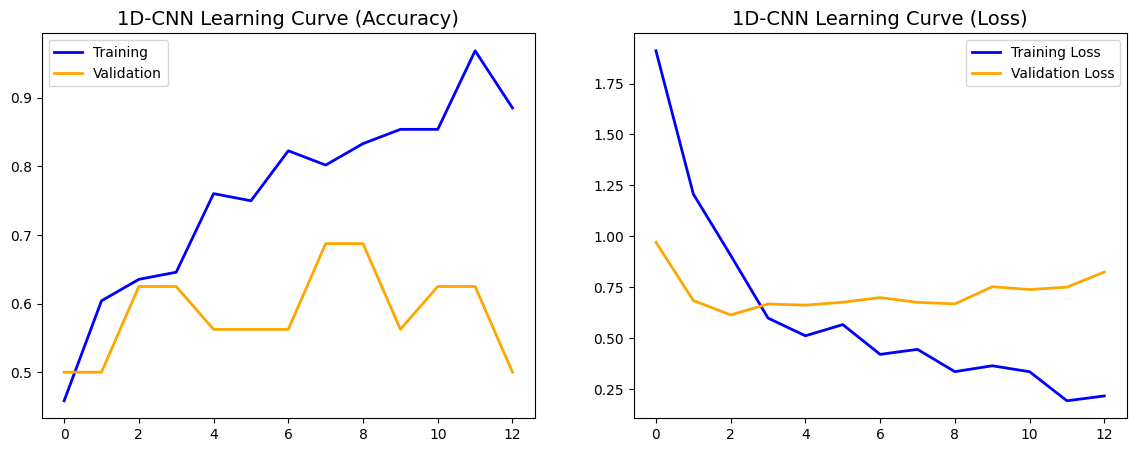

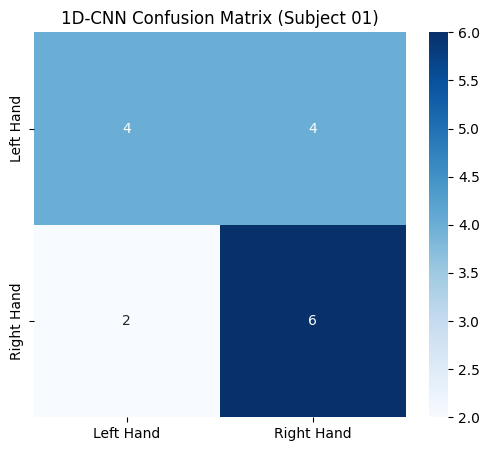

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating Visualizations for Subject 01...")
if "01" in preprocessed_cache:
    X, y, _ = preprocessed_cache["01"]
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_tr_aug, y_tr_aug = create_overlapping_windows(X_tr_raw, y_tr)
    X_te_aug, y_te_aug = create_overlapping_windows(X_te_raw, y_te, window_size=1000, step_size=1000)

    X_tr_dl = np.transpose(normalize_data(X_tr_aug), (0, 2, 1))
    X_te_dl = np.transpose(normalize_data(X_te_aug), (0, 2, 1))

    tf.keras.backend.clear_session()
    cnn_viz = build_1d_cnn(Chans=30, Samples=X_tr_dl.shape[1])

    history = cnn_viz.fit(X_tr_dl, y_tr_aug, epochs=100, batch_size=16,
                          validation_data=(X_te_dl, y_te_aug),
                          callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                          verbose=0)

    # 1. Plot Curves
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training', color='blue', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation', color='orange', linewidth=2)
    plt.title('1D-CNN Learning Curve (Accuracy)', fontsize=14)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    plt.title('1D-CNN Learning Curve (Loss)', fontsize=14)
    plt.legend()
    plt.show()

    # 2. Confusion Matrix
    y_pred = (cnn_viz.predict(X_te_dl, verbose=0) > 0.5).astype(int).flatten()
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_te_aug, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['Left Hand', 'Right Hand'], yticklabels=['Left Hand', 'Right Hand'])
    plt.title('1D-CNN Confusion Matrix (Subject 01)')
    plt.show()

### Final Performance Overview
A consolidated table proving experimental progression from Traditional to Deep Learning.


In [ ]:
print(" FINAL MODEL PERFORMANCE COMPARISON")
results = {
    "Model Architecture": ["CSP + LDA (Baseline)", "FBCSP + SVM (Paper Method)", "FBTS + SVM (Riemannian)", "EEGNet (Deep Learning)", "1D-CNN (Deep Learning)"],
    "Validation Method": ["5-Fold CV", "5-Fold CV", "5-Fold CV", "80/20 Train-Test", "80/20 Train-Test"],
    "Accuracy (%)": [f"{np.mean(csp_motor_scores)*100:.2f}%", f"{np.mean(fbcsp_scores)*100:.2f}%", f"{np.mean(fbts_scores)*100:.2f}%",
                     f"{np.mean(eegnet_scores)*100:.2f}%", f"{np.mean(cnn_scores)*100:.2f}%"]
}
df = pd.DataFrame(results)
print(df.to_string(index=False))

 FINAL MODEL PERFORMANCE COMPARISON
        Model Architecture Validation Method Accuracy (%)
      CSP + LDA (Baseline)         5-Fold CV       51.60%
FBCSP + SVM (Paper Method)         5-Fold CV       52.10%
   FBTS + SVM (Riemannian)         5-Fold CV       54.15%
    EEGNet (Deep Learning)  80/20 Train-Test       63.00%
    1D-CNN (Deep Learning)  80/20 Train-Test       64.25%
